# Apply LLM Features + Compare to Baselines
### The climax of the study: take each LLM × prompt feature set, train all 3 ML algorithms with those features added, and compare against baselines. Total: **180 experiments**.

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import json
import time

import pandas as pd
import numpy as np

from src.config import RESULTS_DIR
from src.data_loader import load_churn, load_housing, load_bank
from src.feature_engineer import apply_features
from src.models import evaluate_cv

### Load datasets and LLM suggestions
##### Reload `llm_suggestions.json` from notebook 03. The 20/20 confirmation per dataset means every LLM × prompt combination produced parseable output.

In [2]:
datasets = {
    "churn": ("classification", load_churn),
    "housing": ("regression", load_housing),
    "bank": ("classification", load_bank),
}

with open(RESULTS_DIR / "llm_suggestions.json") as f:
    all_suggestions = json.load(f)

print(f"Loaded suggestions for {len(all_suggestions)} datasets")
for ds, sets in all_suggestions.items():
    valid_sets = sum(1 for v in sets.values() if v)
    print(f"   {ds}: {valid_sets}/{len(sets)} non-empty (llm × prompt) sets")

Loaded suggestions for 3 datasets
   churn: 20/20 non-empty (llm × prompt) sets
   housing: 20/20 non-empty (llm × prompt) sets
   bank: 20/20 non-empty (llm × prompt) sets


### Build the experiment grid
##### 3 datasets × 20 (LLM × prompt) sets × 3 ML algorithms = **18 experiments**. Each entry captures everything needed to run one job.

In [3]:
models = ["logreg", "random_forest", "xgboost"]

experiments = []
for ds_name, (task, loader) in datasets.items():
    for key in all_suggestions[ds_name].keys():
        for model_name in models:
            experiments.append({
                "dataset": ds_name,
                "task": task,
                "feature_set": f"llm_{key}",
                "model": model_name,
                "key": key,
            })

print(f"{len(experiments)} experiments queued")

180 experiments queued


### Run all 180 experiments
##### For each experiment: apply the LLM's features, train the model with 5-fold CV, record per-fold scores.

In [4]:
all_rows = []
training_errors = []
start = time.perf_counter()

loaded = {ds: loader(verbose=False) for ds, (_, loader) in datasets.items()}

for i, exp in enumerate(experiments, 1):
    ds_name = exp["dataset"]
    X, y = loaded[ds_name]

    suggestions = all_suggestions[ds_name][exp["key"]]
    if not suggestions:
        print(
            f"[{i:3d}/{len(experiments)}] {ds_name:8s} | {exp['key']:30s} | {exp['model']:14s} → SKIPPED (no features)")
        continue

    try:
        X_aug, report = apply_features(
            X, suggestions,
            dataset_name=ds_name,
            llm=exp["key"].split("__")[0],
            prompt_variant=exp["key"].split("__")[1],
            verbose=False,
        )

        # Train + evaluate
        result = evaluate_cv(X_aug, y, exp["model"], exp["task"])

        metric_names = ["accuracy", "f1", "roc_auc"] if exp["task"] == "classification" else ["rmse", "mae", "r2"]

        for m in metric_names:
            for fold_idx, score in enumerate(result[f"{m}_per_fold"]):
                all_rows.append({
                    "dataset": ds_name,
                    "task": exp["task"],
                    "model": exp["model"],
                    "feature_set": exp["feature_set"],
                    "metric": m,
                    "fold": fold_idx,
                    "value": score,
                    "n_features_added": report.n_applied,
                })

        elapsed = time.perf_counter() - start
        print(
            f"[{i:3d}/{len(experiments)}] {ds_name:8s} | {exp['key']:30s} | {exp['model']:14s} ✓  ({elapsed:.0f}s elapsed)")

    except Exception as e:
        elapsed = time.perf_counter() - start
        training_errors.append({**exp, "error": f"{type(e).__name__}: {e}"})
        print(
            f"[{i:3d}/{len(experiments)}] {ds_name:8s} | {exp['key']:30s} | {exp['model']:14s} ✗  ({type(e).__name__})")

print(f"\nTotal: {(time.perf_counter() - start) / 60:.1f} min")
print(f"Successes: {len(experiments) - len(training_errors)}/{len(experiments)}")
print(f"Errors:    {len(training_errors)}")

[  1/180] churn    | gpt-4o-mini__zero_shot         | logreg         ✓  (0s elapsed)
[  2/180] churn    | gpt-4o-mini__zero_shot         | random_forest  ✓  (1s elapsed)
[  3/180] churn    | gpt-4o-mini__zero_shot         | xgboost        ✓  (3s elapsed)
[  4/180] churn    | claude-sonnet__zero_shot       | logreg         ✓  (3s elapsed)
[  5/180] churn    | claude-sonnet__zero_shot       | random_forest  ✓  (4s elapsed)
[  6/180] churn    | claude-sonnet__zero_shot       | xgboost        ✓  (6s elapsed)
[  7/180] churn    | gemini-flash__zero_shot        | logreg         ✓  (6s elapsed)
[  8/180] churn    | gemini-flash__zero_shot        | random_forest  ✓  (7s elapsed)
[  9/180] churn    | gemini-flash__zero_shot        | xgboost        ✓  (9s elapsed)
[ 10/180] churn    | deepseek-v3__zero_shot         | logreg         ✓  (9s elapsed)
[ 11/180] churn    | deepseek-v3__zero_shot         | random_forest  ✓  (10s elapsed)
[ 12/180] churn    | deepseek-v3__zero_shot         | xgboost   

### Merge with baselines into the master results file
##### Concatenate the 9 baseline rows + 180 LLM-augmented rows into `metrics_full.csv`. This is the single source of truth for all downstream analysis.

In [5]:
df_baseline = pd.read_csv(RESULTS_DIR / "metrics.csv")
df_llm = pd.DataFrame(all_rows)

df_all = pd.concat(
    [df_baseline.assign(n_features_added=0), df_llm],
    ignore_index=True,
)

master_path = RESULTS_DIR / "metrics_full.csv"
df_all.to_csv(master_path, index=False)

print(f"Saved to {master_path}")
print(f"   {df_all['feature_set'].nunique()} unique feature sets")
df_all.head()

Saved to /Users/konstantinosevangelidis/PycharmProjects/llm-feature-engineering/results/metrics_full.csv
   21 unique feature sets


,dataset,task,model,feature_set,metric,fold,value,n_features_added
0,churn,classification,logreg,baseline,accuracy,0,0.811923,0
1,churn,classification,logreg,baseline,accuracy,1,0.809084,0
2,churn,classification,logreg,baseline,accuracy,2,0.819730,0
3,churn,classification,logreg,baseline,accuracy,3,0.790483,0
4,churn,classification,logreg,baseline,accuracy,4,0.795455,0


### Did LLM features beat the baseline?
##### For each (dataset, model) pair: compare baseline vs. each LLM/prompt combo on the dataset's primary metric. Reports total wins and the best-performing LLM × prompt for each row.

In [6]:
mean_results = (
    df_all.groupby(["dataset", "model", "feature_set", "metric"])["value"]
    .mean()
    .reset_index()
)

main_metric = {"churn": "roc_auc", "housing": "r2", "bank": "roc_auc"}

print("Did LLM features beat the baseline?\n")
for ds in datasets:
    metric = main_metric[ds]
    print(f"\n{'=' * 70}")
    print(f"{ds.upper()} — main metric: {metric}")
    print('=' * 70)

    sub = mean_results[(mean_results["dataset"] == ds) & (mean_results["metric"] == metric)]
    baseline = sub[sub["feature_set"] == "baseline"].set_index("model")["value"]

    for model in models:
        baseline_val = baseline.get(model, float("nan"))
        llm_rows = sub[(sub["model"] == model) & (sub["feature_set"] != "baseline")].copy()
        llm_rows["delta"] = llm_rows["value"] - baseline_val
        n_wins = (llm_rows["delta"] > 0).sum()
        n_total = len(llm_rows)
        best = llm_rows.loc[llm_rows["value"].idxmax()] if len(llm_rows) else None

        print(f"\n  {model:14s}")
        print(f"     baseline:    {baseline_val:.4f}")
        print(f"     wins:        {n_wins}/{n_total} LLM/prompt combos beat baseline")
        if best is not None:
            print(f"     best LLM:    {best['feature_set'][4:]:30s} → {best['value']:.4f} (Δ {best['delta']:+.4f})")

Did LLM features beat the baseline?


CHURN — main metric: roc_auc

  logreg        
     baseline:    0.8451
     wins:        15/20 LLM/prompt combos beat baseline
     best LLM:    deepseek-v3__with_stats        → 0.8492 (Δ +0.0041)

  random_forest 
     baseline:    0.8217
     wins:        20/20 LLM/prompt combos beat baseline
     best LLM:    gemini-3.1-pro__with_stats     → 0.8295 (Δ +0.0078)

  xgboost       
     baseline:    0.8305
     wins:        17/20 LLM/prompt combos beat baseline
     best LLM:    qwen-2.5__with_stats           → 0.8343 (Δ +0.0038)

HOUSING — main metric: r2

  logreg        
     baseline:    0.8691
     wins:        10/20 LLM/prompt combos beat baseline
     best LLM:    gpt-5.5__with_stats            → 0.8746 (Δ +0.0055)

  random_forest 
     baseline:    0.8963
     wins:        16/20 LLM/prompt combos beat baseline
     best LLM:    gpt-5.5__zero_shot             → 0.9060 (Δ +0.0097)

  xgboost       
     baseline:    0.9125
     wins:        

### Hero chart: baseline vs all LLM features
##### One bar group per ML model, with each LLM/prompt combo as a separate bar. Error bars show fold variance.

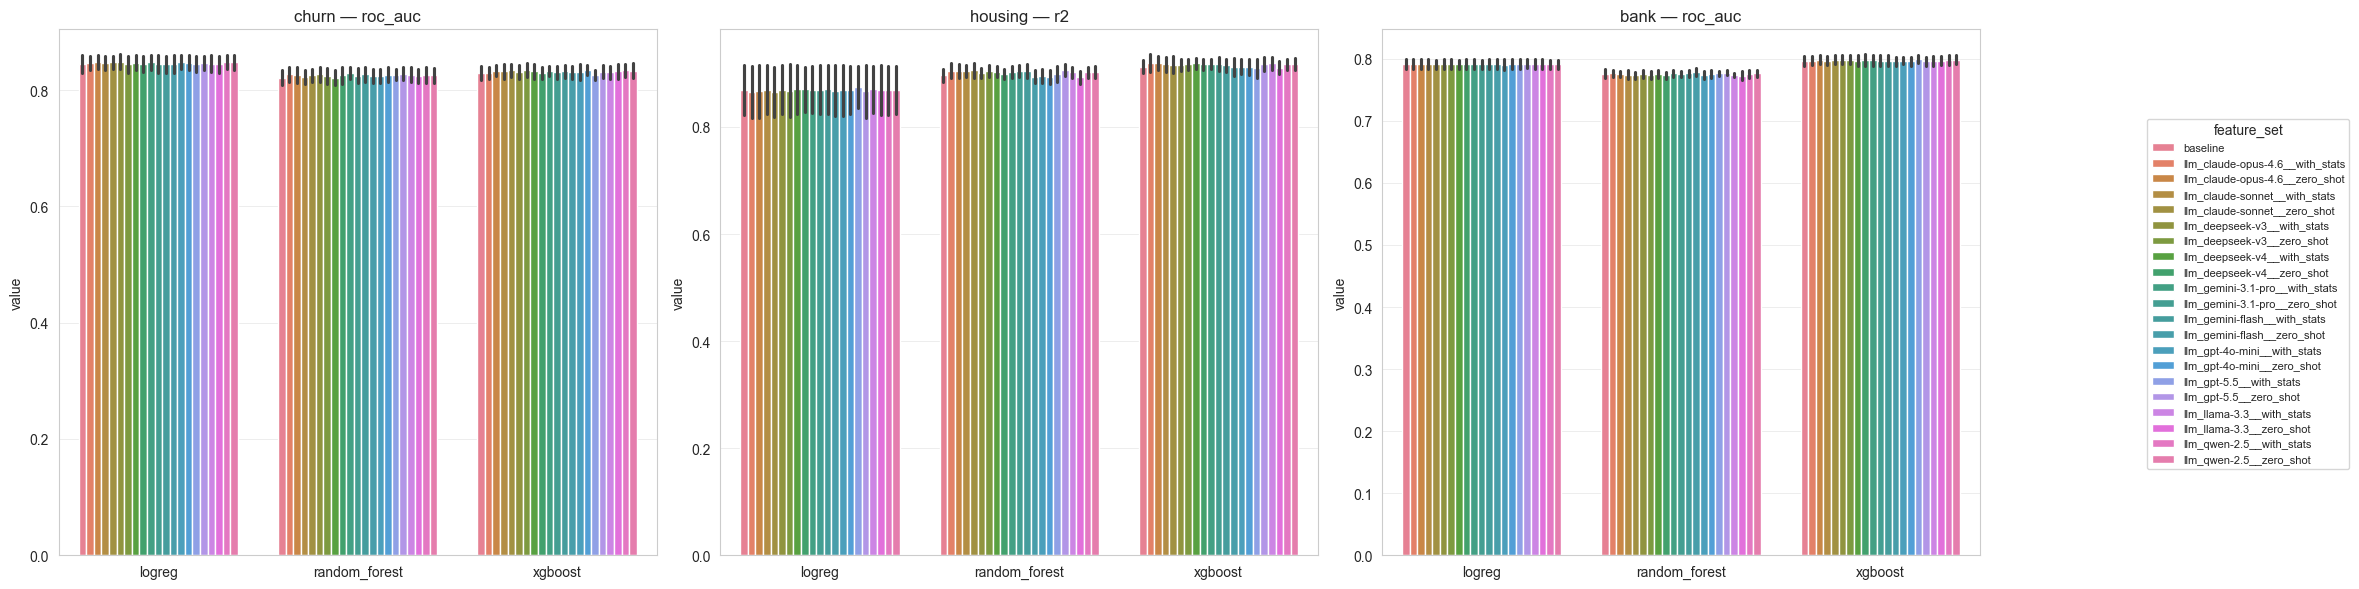

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from src.config import FIGURES_DIR

sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, ds in zip(axes, datasets):
    metric = main_metric[ds]
    sub = df_all[(df_all["dataset"] == ds) & (df_all["metric"] == metric)].copy()

    order = ["baseline"] + sorted(sub[sub["feature_set"] != "baseline"]["feature_set"].unique())

    sns.barplot(
        data=sub, x="model", y="value", hue="feature_set",
        hue_order=order, errorbar="sd", ax=ax,
    )
    ax.set_title(f"{ds} — {metric}")
    ax.legend([], [], frameon=False)
    ax.set_xlabel("")

# Single legend on the side
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center right", bbox_to_anchor=(1.18, 0.5),
           title="feature_set", fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "07_baseline_vs_llm.png", bbox_inches="tight", dpi=120)
plt.show()

### Paired t-tests: are the wins real or sampling noise?
##### For each (dataset, model, LLM/prompt) combo, compare the 5 fold-level scores against baseline using a paired t-test. ✓ marks statistically significant wins (p < 0.05); ✗ marks significant losses.

In [8]:
from scipy.stats import ttest_rel


def get_fold_scores(df, ds, model, feature_set, metric):
    rows = df[
        (df["dataset"] == ds)
        & (df["model"] == model)
        & (df["feature_set"] == feature_set)
        & (df["metric"] == metric)
    ]
    return rows.sort_values("fold")["value"].values


print("Paired t-tests: each LLM/prompt combo vs. baseline\n")
print(f"{'dataset':10s} {'model':14s} {'feature_set':35s} {'Δ':>10s} {'p-value':>10s}")
print("-" * 90)

sig_wins = []

for ds in datasets:
    metric = main_metric[ds]
    for model in models:
        baseline_scores = get_fold_scores(df_all, ds, model, "baseline", metric)

        llm_sets = df_all[
            (df_all["dataset"] == ds)
            & (df_all["model"] == model)
            & (df_all["feature_set"] != "baseline")
            & (df_all["metric"] == metric)
        ]["feature_set"].unique()

        for fs in llm_sets:
            llm_scores = get_fold_scores(df_all, ds, model, fs, metric)
            if len(llm_scores) != len(baseline_scores):
                continue

            t, p = ttest_rel(llm_scores, baseline_scores)
            delta = llm_scores.mean() - baseline_scores.mean()
            sig = "✓" if p < 0.05 and delta > 0 else "✗" if p < 0.05 else " "

            if p < 0.05 and delta > 0:
                sig_wins.append(
                    {
                        "dataset": ds,
                        "model": model,
                        "feature_set": fs,
                        "delta": delta,
                        "p": p,
                    }
                )
            print(
                f"{ds:10s} {model:14s} {fs[4:]:35s} {delta:+10.4f} {p:>10.4f} {sig}"
            )

print(f"\nStatistically significant improvements: {len(sig_wins)}")

Paired t-tests: each LLM/prompt combo vs. baseline

dataset    model          feature_set                                  Δ    p-value
------------------------------------------------------------------------------------------
churn      logreg         gpt-4o-mini__zero_shot                 +0.0025     0.2266  
churn      logreg         claude-sonnet__zero_shot               +0.0028     0.1654  
churn      logreg         gemini-flash__zero_shot                -0.0005     0.3247  
churn      logreg         deepseek-v3__zero_shot                 -0.0005     0.1255  
churn      logreg         llama-3.3__zero_shot                   -0.0004     0.3359  
churn      logreg         qwen-2.5__zero_shot                    +0.0029     0.1340  
churn      logreg         gpt-4o-mini__with_stats                +0.0034     0.1440  
churn      logreg         claude-sonnet__with_stats              +0.0019     0.3830  
churn      logreg         gemini-flash__with_stats               +0.0000     0.8475  

### Improvement heatmap: which LLMs help which models?
##### Heatmap of Δ(metric) for every LLM × ML model combination, per dataset. Green = improvement, red = regression.

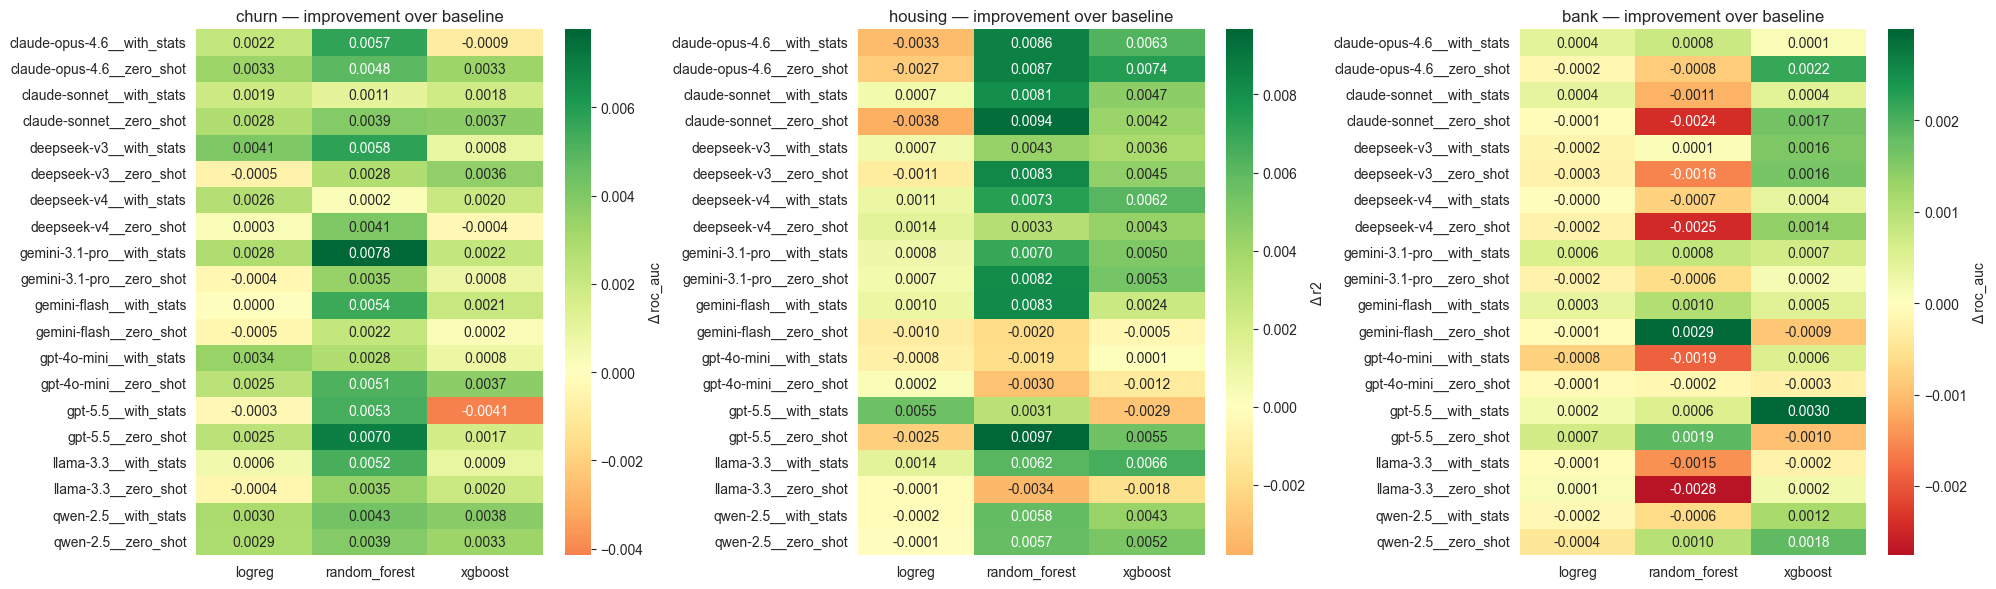

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, ds in zip(axes, datasets):
    metric = main_metric[ds]
    sub = mean_results[(mean_results["dataset"] == ds) & (mean_results["metric"] == metric)].copy()

    # Pivot to model × feature_set
    baseline = sub[sub["feature_set"] == "baseline"].set_index("model")["value"]
    sub = sub[sub["feature_set"] != "baseline"].copy()
    sub["delta"] = sub.apply(lambda r: r["value"] - baseline.get(r["model"], np.nan), axis=1)
    sub["short_fs"] = sub["feature_set"].str.replace("llm_", "")

    pivot = sub.pivot(index="short_fs", columns="model", values="delta")

    sns.heatmap(pivot, annot=True, fmt=".4f",
                cmap="RdYlGn", center=0,
                ax=ax, cbar_kws={"label": f"Δ {metric}"})
    ax.set_title(f"{ds} — improvement over baseline")
    ax.set_xlabel("")
    ax.set_ylabel("")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "08_improvement_heatmap.png", bbox_inches="tight", dpi=120)
plt.show()

### Final research summary
##### Aggregate the headline findings: total experiment count, win rate per dataset, count of statistically significant wins, top 5 significant improvements.

In [10]:
print("=" * 70)
print("📊 FINAL RESEARCH SUMMARY")
print("=" * 70)

# Total experiments
total_exp = df_llm[["dataset", "feature_set", "model"]].drop_duplicates().shape[0]
print(f"\nTotal LLM-augmented experiments: {total_exp}")

# How often did LLM features win?
wins_per_ds = {}
for ds in datasets:
    metric = main_metric[ds]
    sub = mean_results[(mean_results["dataset"] == ds) & (mean_results["metric"] == metric)]
    baseline = sub[sub["feature_set"] == "baseline"].set_index("model")["value"]
    llm = sub[sub["feature_set"] != "baseline"].copy()
    llm["delta"] = llm.apply(lambda r: r["value"] - baseline.get(r["model"], np.nan), axis=1)
    wins_per_ds[ds] = (llm["delta"] > 0).sum() / len(llm)

print(f"\nWin rate per dataset (% LLM combos beating baseline):")
for ds, rate in wins_per_ds.items():
    print(f"   {ds:10s}: {rate:.1%}")

# Statistically significant wins
print(f"\nStatistically significant wins: {len(sig_wins)}/{total_exp} (p<0.05)")
if sig_wins:
    print("\nTop 5 significant improvements:")
    df_sig = pd.DataFrame(sig_wins).sort_values("delta", ascending=False).head(5)
    for _, row in df_sig.iterrows():
        print(
            f"   {row['dataset']:8s} | {row['model']:14s} | {row['feature_set'][4:]:30s} | Δ {row['delta']:+.4f} (p={row['p']:.4f})")

📊 FINAL RESEARCH SUMMARY

Total LLM-augmented experiments: 180

Win rate per dataset (% LLM combos beating baseline):
   churn     : 86.7%
   housing   : 70.0%
   bank      : 51.7%

Statistically significant wins: 39/180 (p<0.05)

Top 5 significant improvements:
   housing  | random_forest  | gpt-5.5__zero_shot             | Δ +0.0097 (p=0.0004)
   housing  | random_forest  | claude-sonnet__zero_shot       | Δ +0.0094 (p=0.0134)
   housing  | random_forest  | claude-opus-4.6__zero_shot     | Δ +0.0087 (p=0.0188)
   housing  | random_forest  | claude-opus-4.6__with_stats    | Δ +0.0086 (p=0.0259)
   housing  | random_forest  | deepseek-v3__zero_shot         | Δ +0.0083 (p=0.0010)
